### The objective of this project is to build and evaluate supervised machine learning models for diabetes prediction, with a strong focus on model comparison and interpretability.

---





### Disease risk score:

## **p = P(disease | features )**

### 0) Import necessary modules

In [1]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score,make_scorer
from sklearn.linear_model import LinearRegression,LogisticRegression

### 1) Load the dataset 

### Inside my local folder is csv file with a dataset

### I will check the folder structure and choose the dataset for this analysis


In [2]:
current_dir = os.getcwd()
dataset = []
files = glob.glob('diabetes_prediction_dataset.csv',root_dir = current_dir, recursive=True)    
if files:
    print(f'Found file {files}')
    dataset.append(files[0])
    
else:
    print('no requested file')

Found file ['diabetes_prediction_dataset.csv']


In [3]:
# complete path
file_path = os.path.join(current_dir,files[0])

In [4]:
# Load dataset into pandas

dataframe = pd.read_csv(file_path)
dataframe['blood_glucose_level'].isna().any()

np.False_

In [5]:
dataframe.shape
#(100000, 9)

(100000, 9)

In [6]:
dataframe['blood_glucose_level'].isna().value_counts()

blood_glucose_level
False    100000
Name: count, dtype: int64

In [7]:
dataframe.head()
dataframe.columns
# ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
# 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [8]:
dataframe.info()
# age - float ?
# gender - string -> need to change it to 0 or 1
# smoking_history -> string , has nulls in form of 'No information' #Nominal value (no order)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [9]:
# check dupllicates
dataframe.duplicated().any()
# yes
dataframe.duplicated()
dataframe.drop_duplicates(keep='first',inplace=True)
# keep the first copy!

In [10]:
dataframe.duplicated().any()
# False 

np.False_

In [11]:
# check for nulls
dataframe.isnull().any()
# False


gender                 False
age                    False
hypertension           False
heart_disease          False
smoking_history        False
bmi                    False
HbA1c_level            False
blood_glucose_level    False
diabetes               False
dtype: bool

### __smoking_history__ column has several values:

- No Info

- never

- former

- current

- not current

- ever

### Value redundancy between `former` and `not_current` 

#### `ever` -> means that person had been smoking before so it is fine to merge into `former`

### My next step:

- merge `not_current` into `former` 

- merge `ever` into `former`

In [12]:
dataframe_col = dataframe['smoking_history']
dataframe_col.value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

In [13]:
dataframe['smoking_history'] = dataframe['smoking_history'].replace('not current','former')
dataframe['smoking_history'] = dataframe['smoking_history'].replace('ever','former')
dataframe['smoking_history'].value_counts()


smoking_history
never      34398
No Info    32887
former     19664
current     9197
Name: count, dtype: int64

In [14]:
# One-hot encoding for this column
# create discrete feature for every info in smoking_history column
dataframe = pd.get_dummies(dataframe,drop_first=False,dtype=int)

#Convert False = 0 and True = 1


In [15]:
mapper = {
    False:0,
    True:1
}

In [16]:
dataframe['smoking_history_current']= dataframe['smoking_history_current'].replace(mapper)


In [17]:
dataframe.drop(columns={'gender_Other'},inplace=True)

### Dataframe has been cleaned from categorical data, `dummy columns` have are made for nominal values

> one hot encoding done

In [18]:
# saving cleaned df in cleaned_df variable
cleaned_df = dataframe
cleaned_df.count()

age                        96146
hypertension               96146
heart_disease              96146
bmi                        96146
HbA1c_level                96146
blood_glucose_level        96146
diabetes                   96146
gender_Female              96146
gender_Male                96146
smoking_history_No Info    96146
smoking_history_current    96146
smoking_history_former     96146
smoking_history_never      96146
dtype: int64

### Check the values in columns

### there should be no big gap between numerical values for the model

### Feature Scalling

## For Linear Models (also `classification` models)

- standardization is required because if data such as __blood_glucoose_level__ has a higher range of values, it will give more weight in the model

- MSE will also be bigger for this feature

In [19]:
cleaned_df['blood_glucose_level'].count()
#max 300
#min 80
# Standard scaler?

np.int64(96146)

## Z-Score

### z = Xi - np.mean(x)/ std

In [20]:
from sklearn.preprocessing import StandardScaler


## Note from scikit-learn documentation

**StandardScaler is sensitive to outliers, and the features may scale differently from each other in the presence of outliers.**

### __Outlier detection no1__

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
cleaned_df.drop_duplicates(keep='first',inplace=True)

In [22]:
selected_features = cleaned_df[['bmi','HbA1c_level','blood_glucose_level']]
selected_features.columns

Index(['bmi', 'HbA1c_level', 'blood_glucose_level'], dtype='object')

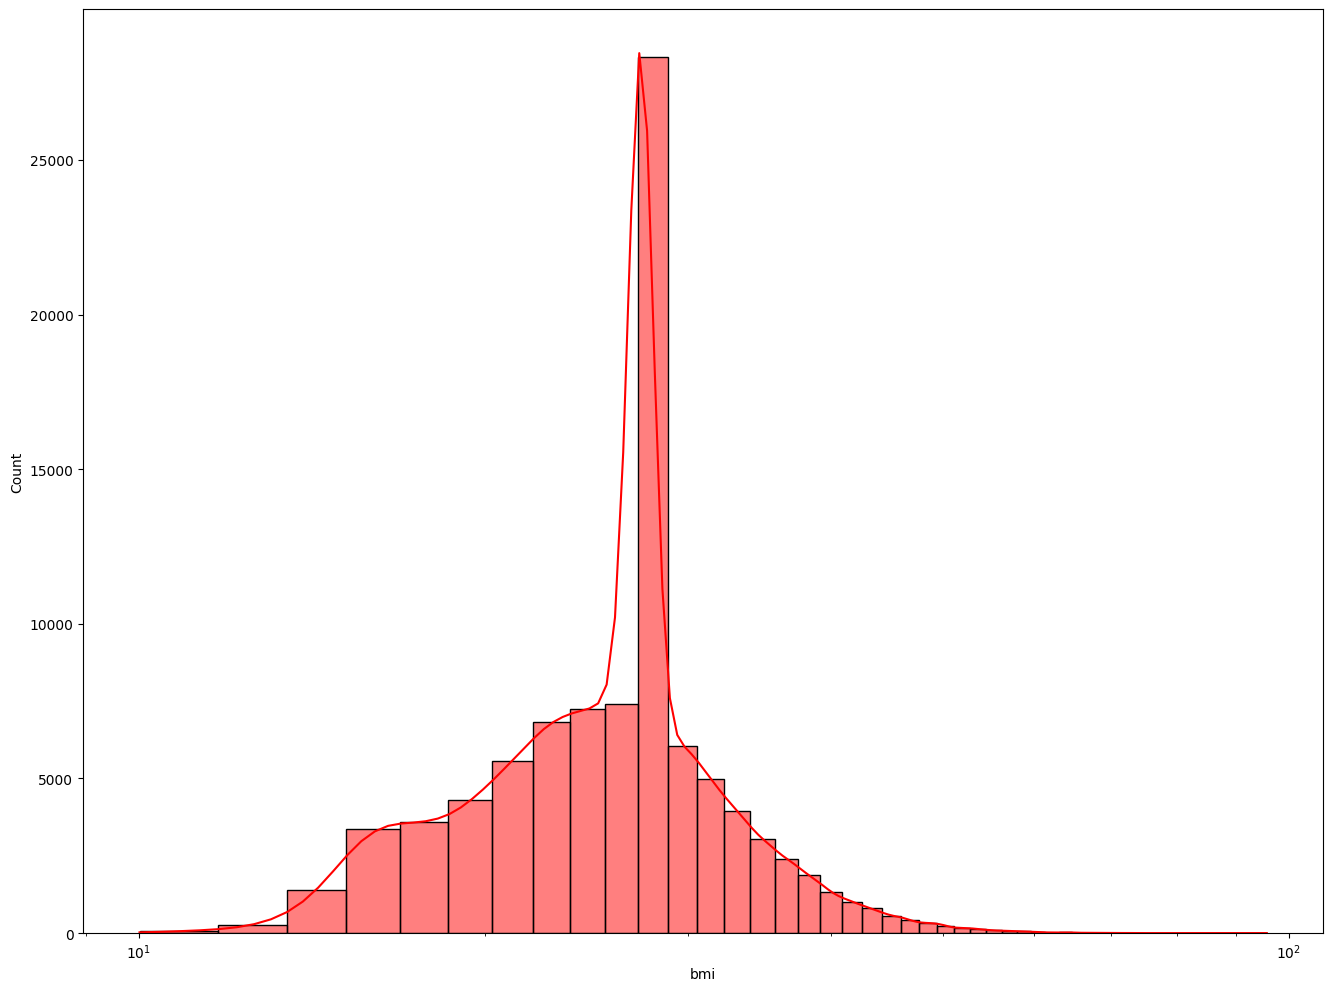

In [23]:
    plt.figure(figsize=(16,12))
    sns.histplot(selected_features['bmi'],kde=True,bins=50,color='red')
    plt.xscale('log') # Log scale, still present

### Big outlier in BMI

In [24]:
selected_features['bmi'].max() #95.69
selected_features['bmi'].min() #10.01
selected_features['bmi'].mean() #27.32
selected_features['bmi'].median() #27.32

np.float64(27.32)

<Axes: ylabel='bmi'>

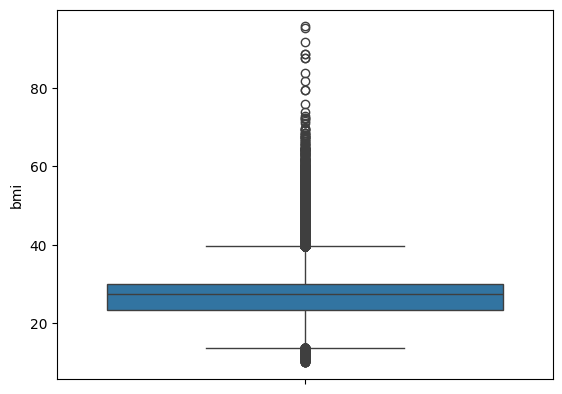

In [25]:
sns.boxplot(selected_features['bmi'])

IQR - > Interquartile range 

__Q3-Q1__

> Outliers in this case are defined as the observations that are below (Q1 − 1.5x IQR) 

### **OR** 

> boxplot lower whisker or above (Q3 + 1.5x IQR) or boxplot upper whisker. It can be visually represented by the box plot.

### Obvious indicator of outlier presenece and my data is skewed to the right

<Axes: >

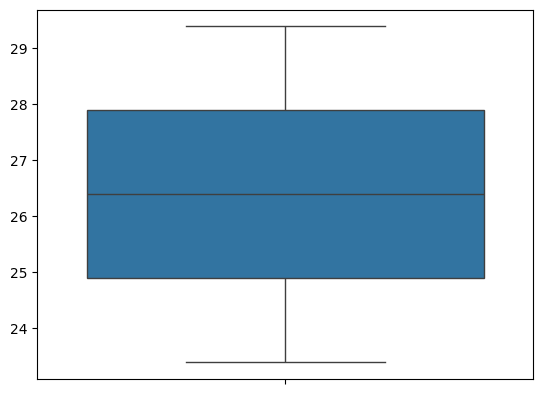

In [26]:
q25 = np.quantile(selected_features['bmi'],q=.25)
q25
q75 = np.quantile(selected_features['bmi'],q=.75)
q75
iqr = q75-q25
no_outlier = np.arange(q25,q75)
sns.boxplot(no_outlier)

### lower outlier cutoff

In [27]:

lower_cutoff = q25 - 1.5 * iqr
upper_cutoff = q75 + 1.5 * iqr

In [28]:
selected_features_outlierCuttof = selected_features[(selected_features['bmi'] < lower_cutoff)|(selected_features['bmi'] > upper_cutoff)]
print(selected_features_outlierCuttof.shape[0])

# 4940 outliers

5307


In [29]:
cleaned_df
selected_features = cleaned_df.iloc[:,3:6]
selected_features


,bmi,HbA1c_level,blood_glucose_level
0,25.19,6.6,140
1,27.32,6.6,80
2,27.32,5.7,158
3,23.45,5.0,155
4,20.14,4.8,155
...,...,...,...
99994,24.60,4.8,145
99996,17.37,6.5,100
99997,27.83,5.7,155
99998,35.42,4.0,100


### __RobustScaler__

- uses IQR ( not mean() and std() like `standardScaler`)

- better option when outliers are present


In [30]:
from sklearn.preprocessing import RobustScaler

In [31]:
robust_scaler = RobustScaler()
scaled_data = robust_scaler.fit_transform(selected_features)
# Fit and transform data to scaled data
scaled_df = pd.DataFrame(scaled_data,columns=selected_features.columns)
# get it back to dataframe object


In [32]:
scaled_df.isnull().any()

bmi                    False
HbA1c_level            False
blood_glucose_level    False
dtype: bool

### Integrate scaled dataframe to cleaned_df and lets see:

In [33]:
cleaned_df.iloc[:,3:6] = scaled_df
cleaned_df.isnull().any()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15284\3487465055.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        0.000000
1       -1.016949
2        0.305085
3        0.254237
4        0.254237
           ...   
95963    0.084746
95964   -0.677966
95965    0.254237
95966   -0.677966
95967   -0.847458
Name: blood_glucose_level, Length: 95968, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cleaned_df.iloc[:,3:6] = scaled_df


age                        False
hypertension               False
heart_disease              False
bmi                        False
HbA1c_level                False
blood_glucose_level         True
diabetes                   False
gender_Female              False
gender_Male                False
smoking_history_No Info    False
smoking_history_current    False
smoking_history_former     False
smoking_history_never      False
dtype: bool

In [34]:
cleaned_df.head()
cleaned_df.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Female', 'gender_Male',
       'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_former', 'smoking_history_never'],
      dtype='object')

In [35]:
cleaned_df.corr()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_former,smoking_history_never
age,1.000000,0.257740,0.238799,0.345150,0.107213,0.006736,0.265498,0.028664,-0.028459,-0.293857,0.033800,0.238403,0.070099
hypertension,0.257740,1.000000,0.119991,0.148150,0.081503,0.009765,0.195669,-0.014073,0.014184,-0.111922,0.015506,0.070310,0.042272
heart_disease,0.238799,0.119991,1.000000,0.061393,0.068208,0.005887,0.170705,-0.078463,0.078547,-0.048431,0.005943,0.093279,-0.033963
bmi,0.345150,0.148150,0.061393,1.000000,0.084499,0.008493,0.214962,0.023504,-0.023509,-0.229463,0.053938,0.126066,0.088242
HbA1c_level,0.107213,0.081503,0.068208,0.084499,1.000000,0.003025,0.406587,-0.019946,0.019992,-0.044503,0.005470,0.038163,0.008673
blood_glucose_level,0.006736,0.009765,0.005887,0.008493,0.003025,1.000000,0.017371,0.002481,-0.002479,-0.004626,-0.001376,0.005057,0.001182
diabetes,0.265498,0.195669,0.170705,0.214962,0.406587,0.017371,1.000000,-0.037659,0.037779,-0.113036,0.016865,0.093905,0.022748
gender_Female,0.028664,-0.014073,-0.078463,0.023504,-0.019946,0.002481,-0.037659,1.000000,-0.999614,-0.055050,-0.025835,-0.034483,0.099269
gender_Male,-0.028459,0.014184,0.078547,-0.023509,0.019992,-0.002479,0.037779,-0.999614,1.000000,0.055061,0.025961,0.034204,-0.099123
smoking_history_No Info,-0.293857,-0.111922,-0.048431,-0.229463,-0.044503,-0.004626,-0.113036,-0.055050,0.055061,1.000000,-0.235071,-0.364456,-0.539691


In [36]:
cleaned_df = cleaned_df.dropna()
y = cleaned_df['diabetes']
X = cleaned_df.drop(columns='diabetes')
X.shape

(92227, 12)

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,roc_curve

In [38]:
## Split data into train_test

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,shuffle=True,random_state=12)
regressor = LogisticRegression(class_weight='balanced', max_iter=1000)
regressor.fit(X_train,y_train)
y_hat = regressor.predict(X_test) #
y_proba_positive = regressor.predict_proba(X_test)[:,1]

In [39]:
print(X.shape)
print(y.shape)

(92227, 12)
(92227,)


**Y_hat** - > predicted classes

__y_proba__ - > probabilities

In [40]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_hat)
score
# 0.888037928519329

0.8331887672124038

In [41]:
y_train.value_counts(normalize=True)

diabetes
0    0.910926
1    0.089074
Name: proportion, dtype: float64

In [42]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
y_hat.shape

(18446,)

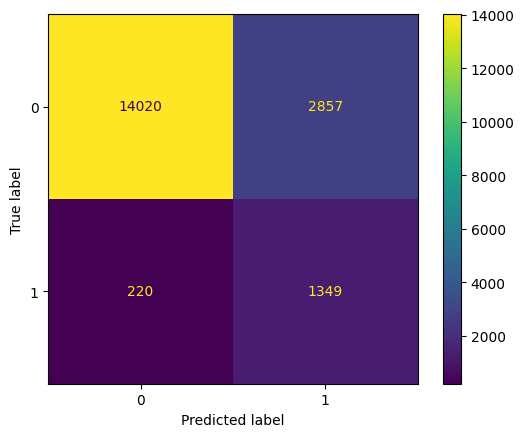

In [43]:
cm = confusion_matrix(y_test,y_hat)
display1=ConfusionMatrixDisplay(cm,display_labels=[0,1])
display1.plot()

In [44]:
print(cm)

[[14020  2857]
 [  220  1349]]


In [45]:
y_hat.shape

(18446,)

True negative (0,0) - 15607

True positive (1,1) - 1438

False positive(0,1) - 1948

False negative (1,0) - 201


**Confusion matrix** explanation :

from total predicted number of values which is 19194, a lot of prediction is `false positive` which regards to 

`precision` score is 0.42 for the label = 1 


Precision score for `true negative` is 0.99 and that regards to label 0, and the total number of true negatives is **15607**

### Classification report:

In [46]:
from sklearn.metrics import classification_report

In [47]:
classification_reportLogistic = classification_report(y_test,y_hat) #1st
print(classification_reportLogistic)

              precision    recall  f1-score   support

           0       0.98      0.83      0.90     16877
           1       0.32      0.86      0.47      1569

    accuracy                           0.83     18446
   macro avg       0.65      0.85      0.68     18446
weighted avg       0.93      0.83      0.86     18446



### Logistic regression:

## 1) Linear formula - This is just `score`

- z = b + w1x1 +w2x2 ... + errors

## 2) Sigmoid formula

sigmoid transformation of linear formula

Gives probability that class is 1

p = σ(z) = 1 / 1-e-z

## 3) Threshold set with proba

Cell down is just for explanation

In [48]:
# proba gives probability of Y that class is 1 or 0

#p = regressor.predict_proba(X_test) # predict probability from X - features ([prob. of 0, prob. of 1])
# p.shape
# Shape is 19194 rows and 2 columns
# First column is class is 0
# Second colums is class is 1 ! -> I will always check 1

### Binary classification -> Patient will develop diabetes (`1`) or patient will not develop diabetes (`0`)

- It's better to have false positive than false negative

- if that is the case here, threshold should be `lower` - > more POSITIVE (1)

When I + threshold up to 90% , model with 90% accuracy predicts the True positives, but i have less total 1's that are positive (`recall` <)

- with high tresholds, many positives with p=[ 0.3, 0.4, 0.7] will be CLASSIFIED AS False negatives!

### In short, when treshold is 0.9:

- ## Predict 1s only if you are 100% sure

- ## For diabetes case, lower threshold so I can have more False negative

---

### ROC-AUC curve

- How well model distinguishes between both classes

### Example: 

####  ROC-AUC = 0.85 -> here's an 85% chance that a randomly selected positive example will receive a higher prediction score than a randomly selected negative example

y - TRUE POSITIVE RATE

x - FALSE POSITIVE RATE

In [49]:
from sklearn.metrics import roc_curve,RocCurveDisplay,auc,f1_score


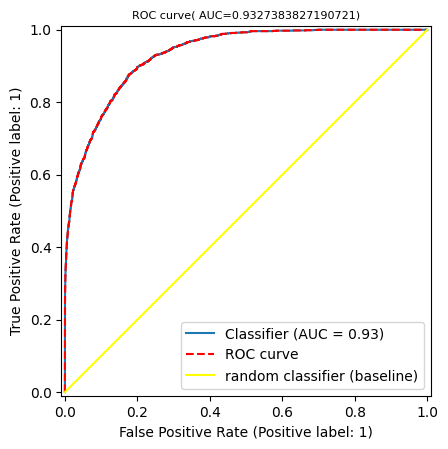

In [50]:
# Get thresholds from both ROC curve and PR curve
# baseline model will be no_skill variable
roc_curve_1 = roc_curve(y_test,y_proba_positive)
roc_true_positive_rate, roc_false_positive_rate, roc_thresholds = roc_curve_1
roc_display = RocCurveDisplay.from_predictions(y_test,y_proba_positive)
roc_display.ax_.set_title(f'ROC curve( AUC={roc_auc_score(y_test,y_proba_positive)})').set_fontsize(8)
no_skill_prob = y_test.replace(1,0)
no_skill_roc_curve_1 = roc_curve(y_test,no_skill_prob)
no_skill_tpr,no_skill_fpr, _ = no_skill_roc_curve_1
plt.plot(roc_true_positive_rate,roc_false_positive_rate,linestyle='--',color='red',label='ROC curve')
plt.plot(no_skill_tpr,no_skill_fpr,color='yellow',label='random classifier (baseline)')
plt.legend()

### 93% that model will correctly rank a randomly choosen positive example higher than randomly chosen negative example

- model has high rate of true positives and low rate of false positives

In [51]:
def optimal_thresh_youden():
    youden_index = roc_true_positive_rate - roc_false_positive_rate
    valid_threshold = [thr for thr in roc_thresholds if not np.isinf(thr)]
    best_id= valid_threshold[np.argmax(youden_index)]
    return best_id
best_threshold_roc = optimal_thresh_youden()
print(best_threshold_roc)

0.999926827410319


### 0.9999987880657757 as threshold. Not quite good for my dataset

## precision will be very high and recall will be low

### Quite imbalanced data

- TN 16121
- TP 1371
- FP 1434
- FN 268

### **PR CURVE**

- Precision - how many + are actually + TP/TP + FP

- Recall - how many of total positives we have TP / TP + FN   aka **'Sensitivity'**

It describes how good a model is at predicting the positive class

In [52]:
from sklearn.metrics import precision_recall_curve,f1_score,auc,PrecisionRecallDisplay
# input (y_true, prob. of positive class)
# returns precision, recall, threshold
precision_l, recall_l, threshold_l = precision_recall_curve(y_test,y_proba_positive)
f1 = f1_score(y_test,y_hat)
f1
pr_curve_baseline = np.mean(y_test)
print(pr_curve_baseline)
print(f1)


0.08505909140192995
0.4671861471861472


In [53]:
baseline_precision = np.sum(y_test) / len(y_test)

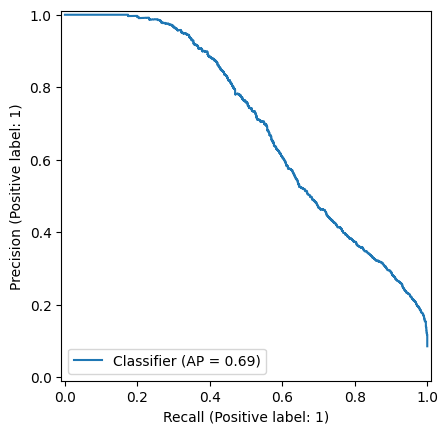

In [54]:
pr_display = PrecisionRecallDisplay.from_predictions(y_test,y_proba_positive)
pr_display

Text(0.5, 0, 'TPR - recall')

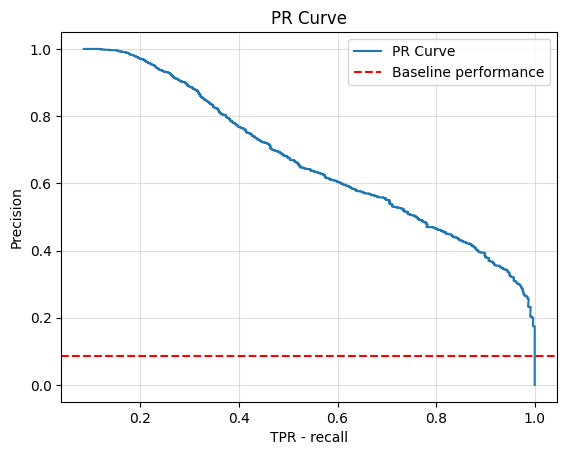

In [55]:
plt.plot(precision_l,recall_l,label='PR Curve')
plt.axhline(y=baseline_precision,linestyle='--',color='red',label='Baseline performance')
plt.legend()
plt.grid(alpha=0.4)
plt.title('PR Curve')
plt.ylabel('Precision')
plt.xlabel('TPR - recall')


PR baseline is positive class mean

A precision-recall curve is a plot of a model's precision (on the y-axis) against its recall (on the x-axis) across all possible thresholds, providing a visual assessment of its performance at different probability cutoffs. It is particularly useful for evaluating classification models, especially with imbalanced datasets, and shows the trade-off between precision and recall—as recall increases, precision often decreases. A higher curve, moving towards the top-right corner of the plot, indicates better performance


### Finding the optimal threshold 

In [56]:
f1_scores = 2 * ((precision_l*recall_l)/(precision_l+recall_l))
f1_idx = np.argmax(f1_scores-1)


In [57]:
pr_threshold_1 = threshold_l[f1_idx]


In [58]:
y_pred_optimal_threshold_pr_1 = (y_proba_positive>=pr_threshold_1).astype(int)

In [59]:
classification_report_2 = classification_report(y_test,y_pred_optimal_threshold_pr_1)
print(classification_report_2)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     16877
           1       0.70      0.56      0.62      1569

    accuracy                           0.94     18446
   macro avg       0.83      0.77      0.79     18446
weighted avg       0.94      0.94      0.94     18446



## compared to baseline 

In [60]:
print(classification_reportLogistic)

              precision    recall  f1-score   support

           0       0.98      0.83      0.90     16877
           1       0.32      0.86      0.47      1569

    accuracy                           0.83     18446
   macro avg       0.65      0.85      0.68     18446
weighted avg       0.93      0.83      0.86     18446



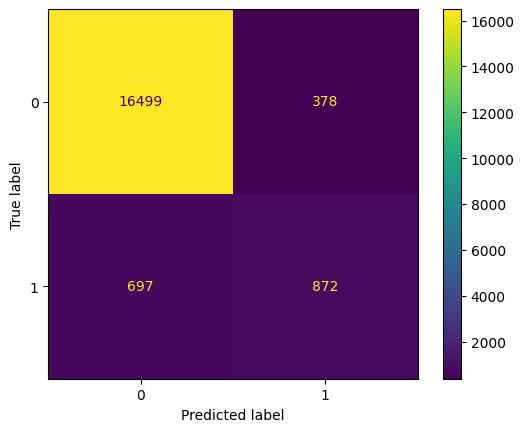

In [61]:
cm_optimized = confusion_matrix(y_test,y_pred_optimal_threshold_pr_1)
cm_optimized_disply = ConfusionMatrixDisplay(cm_optimized,display_labels=[0,1])
cm_optimized_disply.plot()


### From comparing optimized threshold value (`pr_treshold_1`)  with just threshold of 50% for naive model, it is shown that:

- Clear precision-recall tradeoff in optimized model (precision is higher on cost of reducing the recall)

- f1 score is greater for optimized threshold 

### For my dataset:

## Higher recall = better
---

# _Report_:


Diabetes progression is an important parameter of overall health, and understanding the disease and how each factor contributes to this disease is necessary for successful disease detection. In medical screening, catching true positives is most important, but also catching all the false negatives. For this to be successful, we choose the model that has better recall because it is possible to catch the most of the positive patients. If the probability threshold is 10%, we may say that the patient has a high risk factor to be diagnosed with diabetes.

# _Metrics observed_:


- Class imbalance 0>>>1 
- ROC and PR Curve 
- recall > precision 
- f1 score balance between recall and precision

## _Threshold_ choosing based on:

- base model threshold (0.5%) f1 score 
- **PR curve** threshold with Youden's calculation ( `TPR` - `FPR`) 
- **ClassificationReport** observation and choosing the baseline model -> recal > precision , f1 score lower

### 1) feature importance by `coefficient magnitudes`


In [62]:
feature_importance = pd.DataFrame({
    'feature':X.columns,
    'coef':regressor.coef_[0],
    'abs_coef':abs(regressor.coef_[0])
}).sort_values(by='coef',ascending=False)


In [63]:
feature_importance

,feature,coef,abs_coef
4,HbA1c_level,3.018471,3.018471
2,heart_disease,0.844175,0.844175
1,hypertension,0.742584,0.742584
3,bmi,0.612492,0.612492
5,blood_glucose_level,0.077359,0.077359
0,age,0.051061,0.051061
9,smoking_history_current,-0.277811,0.277811
10,smoking_history_former,-0.418759,0.418759
11,smoking_history_never,-0.517696,0.517696
7,gender_Male,-0.909479,0.909479


### Inspecting the weight of the coeficients, seembs that `HbA1c_level` is the highest rated

### Next is blood_glucose_level

### 2) Odds - ratio

In [64]:
feature_importance['odds_ratio'] = np.exp(feature_importance['coef'])
feature_importance

,feature,coef,abs_coef,odds_ratio
4,HbA1c_level,3.018471,3.018471,20.459976
2,heart_disease,0.844175,0.844175,2.326057
1,hypertension,0.742584,0.742584,2.101359
3,bmi,0.612492,0.612492,1.845024
5,blood_glucose_level,0.077359,0.077359,1.080430
0,age,0.051061,0.051061,1.052387
9,smoking_history_current,-0.277811,0.277811,0.757440
10,smoking_history_former,-0.418759,0.418759,0.657863
11,smoking_history_never,-0.517696,0.517696,0.595892
7,gender_Male,-0.909479,0.909479,0.402734


---

## Here i skip the `RandomDecisionTree` model because it has very high tendency for overfitting.

- my dataset is medium size

- medical dataset, very high risk for overfitting

- nonlinear relationship between features 

- dataset with unbalanced class ratio


# **Random Forest**

### Bagging 

### Aggregation of multiple trees

### Detection of most important features

### Robust for outliers and noise



In [65]:
X.shape

(92227, 12)

In [66]:
y.shape

(92227,)

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=40)

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [69]:
rfc = RandomForestClassifier(criterion='gini',random_state=42)

In [70]:
rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [71]:
y_pred_gini = rfc.predict(X_test)

### Test data vs Training data accuracy score comparison, checking if model is overfitting.The difference should be minimal between these 2

In [72]:
# accuracy_score
ac_gini = accuracy_score(y_test,y_pred_gini)
y_train_gini = rfc.predict(X_train)
ac_gini

0.9492572915537244

In [73]:
ac_train_gini = accuracy_score(y_train,y_train_gini)
ac_train_gini

0.9988343882571393

In [74]:
print(f"Model accuracy score with gini criterion is: {ac_gini:.2f}\nTrainig set accuracy score is: {ac_train_gini:.2f}")

Model accuracy score with gini criterion is: 0.95
Trainig set accuracy score is: 1.00


## No overfitting!

-small gap between test and traninig data

### As expected, predicting with training data is 100% correct

## Lets compare models with:

### Gini
`> and`
### Entropy 

In [75]:
y_proba_entropy = rfc.predict_proba(X_test)[:,1]

In [76]:
def evaluate_model(model,X_train,X_test,y_train,y_test,return_predictions=False): 
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    return {
        'accuracy':accuracy_score(y_test,y_pred),
        'precision':precision_score(y_test,y_pred),
        'recall':recall_score(y_test,y_pred),
        'f1_score':f1_score(y_test,y_pred),
        'roc_auc_score':roc_auc_score(y_test,y_proba_entropy)
    }
results_df = pd.DataFrame()
for criterion in ['gini','entropy']:
    rfc = RandomForestClassifier(
        criterion=criterion,
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )
    metrics = evaluate_model(rfc,X_train,X_test,y_train,y_test)
    metrics['criterion'] = criterion
    results_df = pd.concat([results_df,pd.DataFrame([metrics])],ignore_index=True)


In [77]:
print(f'\t[model performance metrics with n_estimators=100]\n{results_df}')

	[model performance metrics with n_estimators=100]
   accuracy  precision    recall  f1_score  roc_auc_score criterion
0  0.948607   0.852222  0.484829  0.618050       0.924556      gini
1  0.948715   0.844902  0.492415  0.622204       0.924556   entropy


In [78]:
def return_prediction(model,X_train,X_test,y_train,y_test,criterion):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    if criterion=='gini':
        model = RandomForestClassifier(
            criterion=criterion,
            n_estimators = 100,
            random_state=42,
            class_weight='balanced'
        )
        return y_pred
    else:
        model = RandomForestClassifier(
            criterion=criterion,
            n_estimators = 100,
            random_state=42,
            class_weight='balanced'
        )
        return y_pred

In [79]:
y_pred_entropy=return_prediction(rfc,X_train,X_test,y_train,y_test,'entropy')

In [80]:
results_df

,accuracy,precision,recall,f1_score,roc_auc_score,criterion
0,0.948607,0.852222,0.484829,0.618050,0.924556,gini
1,0.948715,0.844902,0.492415,0.622204,0.924556,entropy


## Both approaches for calculating infromation gain are similar
### Entropy approach is slightly better

In [81]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [82]:
y_proba_entropy = rfc.predict_proba(X_test)[:,1]
y_test.shape
y_pred_entropy.shape

(18446,)

[[16721   143]
 [  803   779]]


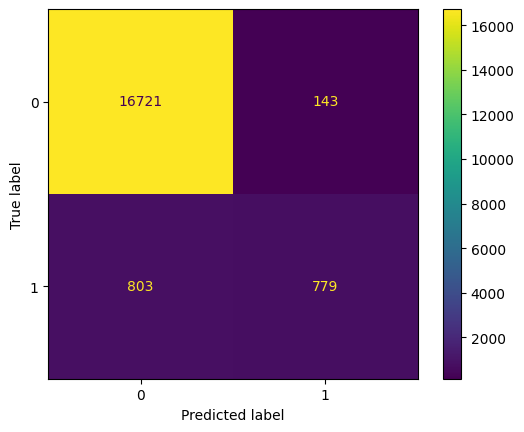

In [83]:
cm_forest = confusion_matrix(y_test,y_pred_entropy)
print(cm_forest)
cm_display_forest = ConfusionMatrixDisplay(cm_forest)
cm_display_forest.plot()

### Too many false positives for this dataset!

In [84]:
# 803 false negatives
# 143 false positives
# 16721 true negatives
# 779 true positives

In [85]:
forest_classReport = classification_report(y_test,y_pred_entropy)
print(forest_classReport)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     16864
           1       0.84      0.49      0.62      1582

    accuracy                           0.95     18446
   macro avg       0.90      0.74      0.80     18446
weighted avg       0.94      0.95      0.94     18446



> addition of new trees does not improve the overfitting but the model performance

In [86]:
print(classification_report_2) # Logistic Regression optimized

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     16877
           1       0.70      0.56      0.62      1569

    accuracy                           0.94     18446
   macro avg       0.83      0.77      0.79     18446
weighted avg       0.94      0.94      0.94     18446



In [87]:
from sklearn.model_selection import RandomizedSearchCV


    Efficiency: Evaluates a fixed number of parameter combinations, making it computationally cheaper than GridSearchCV.

    Random Sampling: Allows sampling from continuous distributions for hyperparameters.

    Cross-Validation: Automatically performs cross-validation to validate each combination of parameters.

    Scoring Metrics: Supports various scoring metrics to optimize model performance.
    
    Parallel Processing: Can utilize multiple CPU cores for faster execution.


In [88]:
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [89]:
def hyperparameter_tuing(X_train,X_test,y_train,y_test,k=False):
    X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=41)
    params = {
        "n_estimators":[100,150,300,500,1000],
        "criterion":['gini','entropy'],
        "min_samples_leaf":[1,2,3],
        "min_samples_split":[2,3,4],
        "bootstrap":[True,False]
    }
    return params

xres = hyperparameter_tuing(X_train,X_test,y_train,y_test,k=False)

In [90]:

random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=xres,
    n_iter=50,
    scoring = 'accuracy',
    cv = 2,
    verbose=2,
)


In [91]:
random_search.fit(X_train,y_train)

Fitting 2 folds for each of 50 candidates, totalling 100 fits
[CV] END bootstrap=True, criterion=entropy, min_samples_leaf=2, min_samples_split=2, n_estimators=150; total time=   4.4s
[CV] END bootstrap=True, criterion=entropy, min_samples_leaf=2, min_samples_split=2, n_estimators=150; total time=   4.8s
[CV] END bootstrap=True, criterion=entropy, min_samples_leaf=3, min_samples_split=3, n_estimators=300; total time=   8.2s
[CV] END bootstrap=True, criterion=entropy, min_samples_leaf=3, min_samples_split=3, n_estimators=300; total time=   9.9s
[CV] END bootstrap=True, criterion=gini, min_samples_leaf=2, min_samples_split=4, n_estimators=500; total time=  15.6s
[CV] END bootstrap=True, criterion=gini, min_samples_leaf=2, min_samples_split=4, n_estimators=500; total time=  16.3s
[CV] END bootstrap=False, criterion=gini, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  26.0s
[CV] END bootstrap=False, criterion=gini, min_samples_leaf=1, min_samples_split=2, n_estimat

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'criterion': ['gini', 'entropy'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [92]:
random_search.best_estimator_
best_params = random_search.best_params_
best_model = random_search.best_estimator_
best_params
best_params

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'criterion': 'entropy',
 'bootstrap': True}

In [93]:
X_test.shape

(18446, 12)

In [94]:

y_pred_cv = best_model.predict(X_test)
y_pred_proba_cv = best_model.predict_proba(X_test)
y_pred_proba_cv# probabilities of negative[0] and positive[1] classes


array([[0.82      , 0.18      ],
       [0.96666667, 0.03333333],
       [0.6       , 0.4       ],
       ...,
       [0.96333333, 0.03666667],
       [1.        , 0.        ],
       [0.03333333, 0.96666667]], shape=(18446, 2))

In [95]:
cv_Forest = classification_report(y_test,y_pred_cv)
print(cv_Forest)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     16864
           1       0.86      0.49      0.63      1582

    accuracy                           0.95     18446
   macro avg       0.91      0.74      0.80     18446
weighted avg       0.95      0.95      0.94     18446



In [96]:
print(forest_classReport)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     16864
           1       0.84      0.49      0.62      1582

    accuracy                           0.95     18446
   macro avg       0.90      0.74      0.80     18446
weighted avg       0.94      0.95      0.94     18446




### RandomizedSearchedCV best_model gave better f1 score and recall for positive class

[]

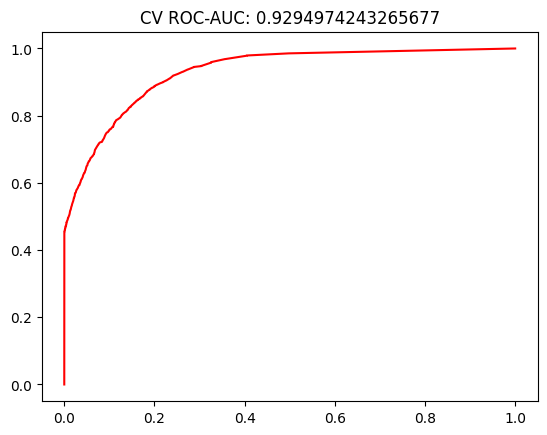

In [97]:
fpr_cv,tpr_cv,threshold_cv = roc_curve(y_test,y_pred_proba_cv[:,1])
plt.plot(fpr_cv,tpr_cv,color='red')
plt.title(f'CV ROC-AUC: {roc_auc_score(y_test,y_pred_proba_cv[:,1])}')
plt.plot()

In [98]:
precision_cv, recall_cv,threshold_cv = precision_recall_curve(y_test,y_pred_proba_cv[:,1])


### Plotting PR curve with best threshold from the tuned RF and also LogisticRegression to see how these 2 models perform

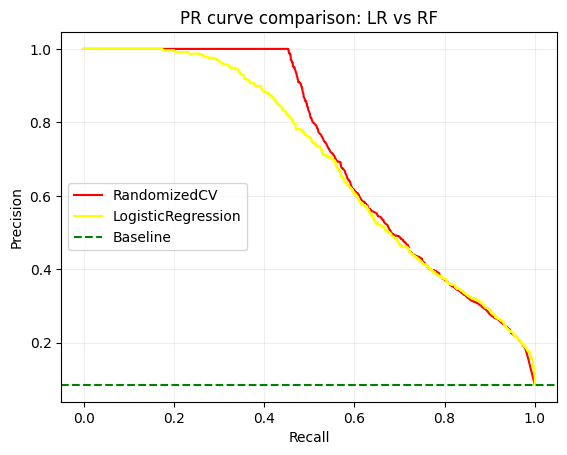

In [99]:
precision_f,recall_f,threshold_f = precision_recall_curve(y_test,y_pred_proba_cv[:,1])
plt.plot(recall_cv,precision_cv,linestyle='-',label='RandomizedCV',color='red')
plt.plot(recall_l,precision_l,linestyle='-',color='yellow',label='LogisticRegression')
plt.axhline(y=np.mean(y_test),linestyle='--',color='green',label='Baseline')
plt.title('PR curve comparison: LR vs RF')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=.2)
plt.legend(loc='center left')
plt.show()

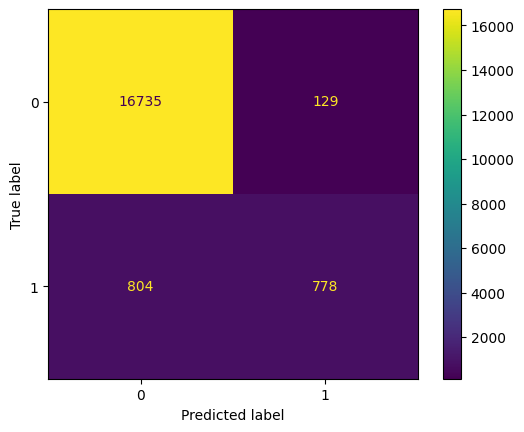

In [100]:
cm_CV = confusion_matrix(y_test,y_pred_cv)
cm_cv_disp = ConfusionMatrixDisplay(cm_CV, display_labels=[0,1])
cm_cv_disp.plot()

### Now we should focus on additional optimization of threshold value

### Depending on the nature of the dataset we may choose the option where we want to optimize the threshold in favor of better `recall` 

#### It can also be optimized with focus on `F1 score` or `precision`

###  Threshold optimization:

#### 1) F1 optimization (Check if we can optimize f1 while not degrading `recall` in this case)

In [101]:
f1 = 2 * (precision_cv[1:len(threshold_cv+1)]*recall_cv[1:len(threshold_cv+1)])/(precision_cv[1:len(threshold_cv+1)]+recall_cv[1:len(threshold_cv+1)])
len(precision_cv)
len(recall_cv)
best_id = np.argmax(f1)
optimal_threshold = threshold_cv[best_id]
optimal_threshold


np.float64(0.5549854714577029)

Lets calculate the custom predictions with a new threshold:

In [102]:
y_pred_cv_custom = (y_pred_proba_cv[:,1]>=optimal_threshold).astype(int)


In [103]:
params = {
    'precision_score':precision_score(y_test,y_pred_cv_custom),
    'recall_scre': recall_score(y_test,y_pred_cv_custom),
    'f1_score':f1_score(y_test,y_pred_cv_custom)
}
params

{'precision_score': 0.9028436018957346,
 'recall_scre': 0.48166877370417194,
 'f1_score': 0.6281945589447651}

In [104]:
### Threshold constraint 0.5

y_pred_cv_custom_2 = (y_pred_proba_cv[:,1]>=0.19).astype(int)

params2 = {
    'precision_score':precision_score(y_test,y_pred_cv_custom_2),
    'recall_scre': recall_score(y_test,y_pred_cv_custom_2),
    'f1_score':f1_score(y_test,y_pred_cv_custom_2)
}
params2

{'precision_score': 0.4734848484848485,
 'recall_scre': 0.7111251580278128,
 'f1_score': 0.5684689236988378}

In [105]:
print(cv_Forest)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     16864
           1       0.86      0.49      0.63      1582

    accuracy                           0.95     18446
   macro avg       0.91      0.74      0.80     18446
weighted avg       0.95      0.95      0.94     18446



In [106]:
classification_report_custom = classification_report(y_test,y_pred_cv_custom_2)
print(classification_report_custom)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     16864
           1       0.47      0.71      0.57      1582

    accuracy                           0.91     18446
   macro avg       0.72      0.82      0.76     18446
weighted avg       0.93      0.91      0.92     18446



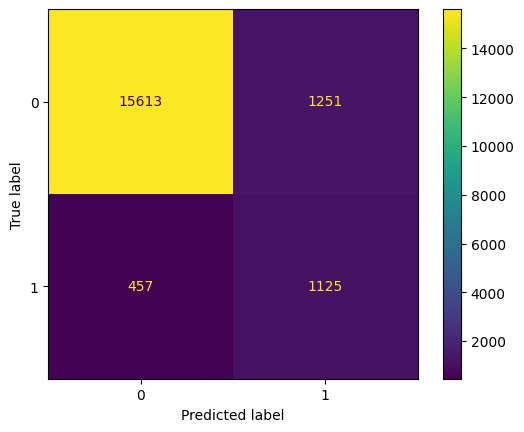

In [107]:
cm_custom = confusion_matrix(y_test,y_pred_cv_custom_2)
ConfusionMatrixDisplay(cm_custom).plot()

### Feature importance scores are a collection of methods all used to answer one question: which machine learning model features have contributed the most to predictions in general? 

In [108]:
from sklearn.ensemble import GradientBoostingClassifier

In [109]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [110]:
y_pred_gbc = gbc.predict(X_test)

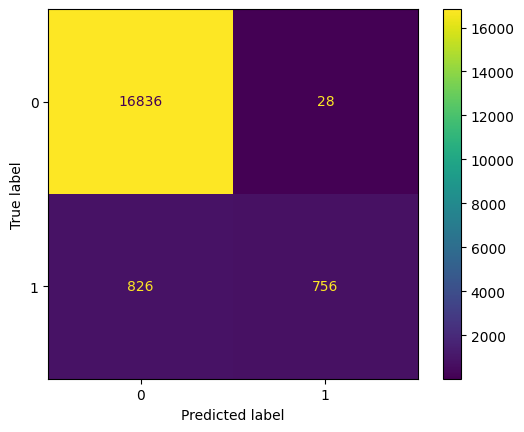

In [111]:
cm_gbc = confusion_matrix(y_test,y_pred_gbc)
ConfusionMatrixDisplay(cm_gbc).plot()
# FP = 28

In [112]:
classification_report_gbc = classification_report(y_test,y_pred_gbc)
print(classification_report_gbc)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     16864
           1       0.96      0.48      0.64      1582

    accuracy                           0.95     18446
   macro avg       0.96      0.74      0.81     18446
weighted avg       0.95      0.95      0.95     18446



In [113]:
y_pred_proba_gbc = gbc.predict_proba(X_test)

[]

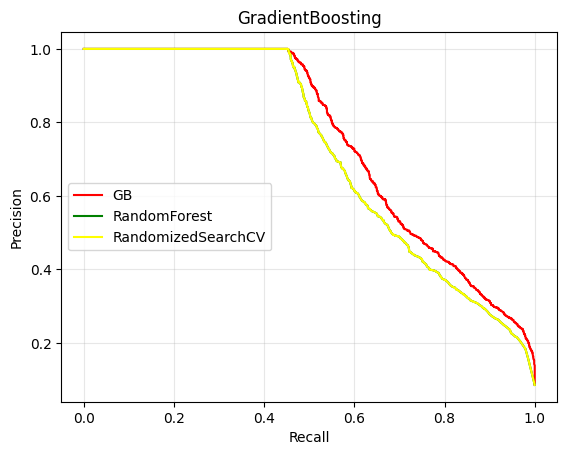

In [114]:
precision_gbc,recall_gbc,threshold_gbc = precision_recall_curve(y_test,y_pred_proba_gbc[:,1])
plt.plot(recall_gbc,precision_gbc,label='GB',color='red')
plt.plot(recall_f,precision_f,label='RandomForest',color='green')
plt.plot(recall_cv,precision_cv,label='RandomizedSearchCV',color='yellow')
plt.title('GradientBoosting')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='center left')
plt.grid(alpha=.3)
plt.plot()

In [115]:
from sklearn.metrics import average_precision_score

In [116]:
avg_precision_gbc = average_precision_score(y_test,y_pred_gbc)
avg_precision_rf = average_precision_score(y_test,y_pred_entropy)
avg_precision_cv = average_precision_score(y_test,y_pred_cv)

In [117]:
print(f"Average precision score for models:\nGradientBoosting: {avg_precision_gbc}\nRandomForest: {avg_precision_rf}\nRandomizedSearchCV: {avg_precision_cv}")

Average precision score for models:
GradientBoosting: 0.505588458359954
RandomForest: 0.4595747985664621
RandomizedSearchCV: 0.4654244217353639


### Because this dataset is extremely imbalanced, ROC - AUC curve is a bad option for an informative metric. It can capture 90% of negatives, and ROC - AUC will still be around 90%

### Instead, the primary evaluation score is PR-AUC, which reflects the model ability to indentify the minority positive class.

In [118]:
## GradientBoost optimization
# RandomizedSearchCV because the model has a lot of parameters so it can be easily overtrained

In [119]:
params = {
    'n_estimators':[50,100,150],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[1,2,3],
    'subsample':[0.2,0.4,0.6]

}

In [120]:
optimizer = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=params,
    n_iter = 10,
    cv=2,
    random_state=42,
    scoring='recall',
    verbose=2
)

In [121]:
optimizer.fit(X_train,y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.6; total time=   7.3s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.6; total time=   7.1s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.4; total time=   2.1s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.4; total time=   2.1s
[CV] END learning_rate=0.01, max_depth=1, n_estimators=100, subsample=0.4; total time=   2.9s
[CV] END learning_rate=0.01, max_depth=1, n_estimators=100, subsample=0.4; total time=   2.9s
[CV] END learning_rate=0.2, max_depth=1, n_estimators=50, subsample=0.6; total time=   1.7s
[CV] END learning_rate=0.2, max_depth=1, n_estimators=50, subsample=0.6; total time=   1.8s
[CV] END learning_rate=0.1, max_depth=1, n_estimators=150, subsample=0.6; total time=   5.3s
[CV] END learning_rate=0.1, max_depth=1, n_estimators=150, subsample=0.6; total time=   5.3s
[CV] END 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [1, 2, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.2, 0.4, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versi

---
best model evaluation

In [134]:
best_optimizer = optimizer.best_estimator_
best_optimizer.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.6
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

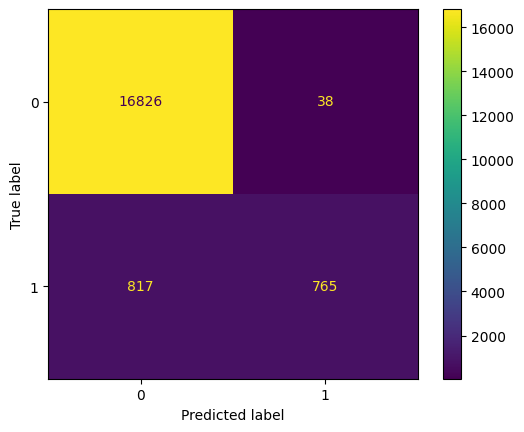

In [143]:
y_best_optimizer = best_optimizer.predict(X_test)
y_best_optimizer_proba = best_optimizer.predict_proba(X_test)
cm_gbc_best = confusion_matrix(y_test,y_best_optimizer)
ConfusionMatrixDisplay(cm_gbc_best).plot()

In [122]:
y_pred_optimizer = optimizer.predict(X_test)
y_pred_proba_optimizer = optimizer.predict_proba(X_test)


end

--- 

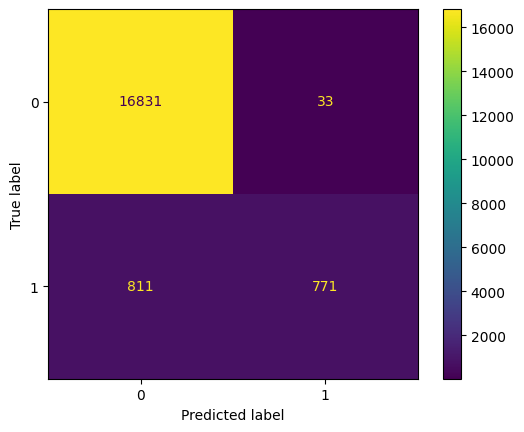

In [123]:
cm_gbc_2= confusion_matrix(y_test,y_pred_optimizer)
ConfusionMatrixDisplay(cm_gbc_2,display_labels=[0,1]).plot()

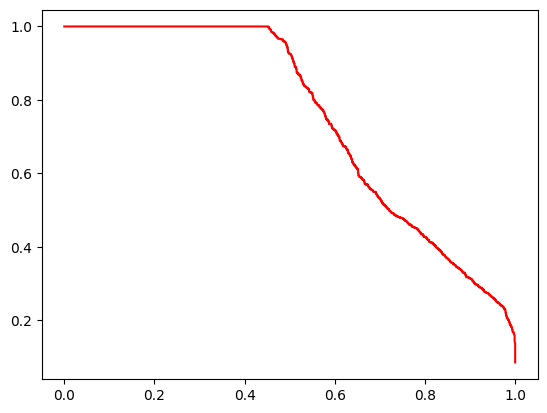

In [124]:
precision_optimizer,recall_optimizer, threshold_optimizer = precision_recall_curve(y_test,y_pred_proba_optimizer[:,1])
plt.plot(recall_optimizer,precision_optimizer,color='red')

### Compare with previous 3

[]

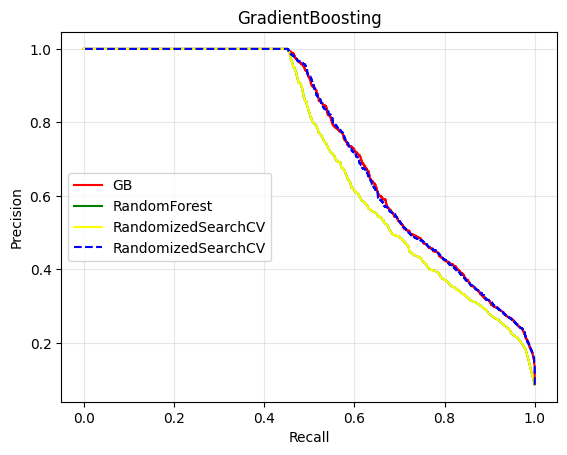

In [125]:
plt.plot(recall_gbc,precision_gbc,label='GB',color='red')
plt.plot(recall_f,precision_f,label='RandomForest',color='green')
plt.plot(recall_cv,precision_cv,label='RandomizedSearchCV',color='yellow')
plt.plot(recall_optimizer,precision_optimizer,color='blue',linestyle='--',label='RandomizedSearchCV')
plt.title('GradientBoosting')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='center left')
plt.grid(alpha=.3)
plt.plot()

### Marginal changes:

- Recall is better for 0.01

- FP is higher for 8 samples

In [126]:
print(classification_report(y_test,y_pred_optimizer))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     16864
           1       0.96      0.49      0.65      1582

    accuracy                           0.95     18446
   macro avg       0.96      0.74      0.81     18446
weighted avg       0.95      0.95      0.95     18446



In [127]:
### Recall is better for 0.01 for this RandomizedCV model approach

## Feature importances analysis

### **Permutation Importances**

### Performs random shuffling of values for the 1 selected feature 

### Inspecting the degradation of the model performance

#### **We can ask, how much model relies on that single feature?**

## It can be used both on:

### `Training data`


### `Validation data` ( here we can capture which features contribute most for model generalization perspective )

In [128]:
from sklearn.inspection import permutation_importance

In [129]:
perm = permutation_importance(gbc,X_test,y_test,n_repeats=30,random_state=42)

In [130]:
mp = perm.importances_mean
col_names = selected_features.columns
for p in mp.argsort()[::-1]:
    if perm.importances_mean[p] - 1.96*perm.importances_std[p] > 0: ## Confidence interval 0.05 if value is < then NUll is rejected
        print(f"{X_test.columns[p]:<15}"
              f"[{perm.importances_mean[p]:.3f}"
              f"+/- {perm.importances_std[p]:.3f}]")

        



HbA1c_level    [0.071+/- 0.001]
bmi            [0.002+/- 0.000]
age            [0.001+/- 0.000]
heart_disease  [0.001+/- 0.000]
hypertension   [0.000+/- 0.000]


### HbA1c_level has the biggest impact on prediction of the outcome!

In [147]:
feature_importance

,feature,coef,abs_coef,odds_ratio
4,HbA1c_level,3.018471,3.018471,20.459976
2,heart_disease,0.844175,0.844175,2.326057
1,hypertension,0.742584,0.742584,2.101359
3,bmi,0.612492,0.612492,1.845024
5,blood_glucose_level,0.077359,0.077359,1.080430
0,age,0.051061,0.051061,1.052387
9,smoking_history_current,-0.277811,0.277811,0.757440
10,smoking_history_former,-0.418759,0.418759,0.657863
11,smoking_history_never,-0.517696,0.517696,0.595892
7,gender_Male,-0.909479,0.909479,0.402734


### Partial dependance plot

While feature importance shows what variables most affect predictions, partial dependence plots show how a feature affects predictions.

Like permutation importance, partial dependence plots are calculated after a model has been fit.

- Change the values of `HbA1c_level` and see how the outcome will change as the selected feature changes

In [150]:
from sklearn.inspection import partial_dependence,PartialDependenceDisplay

In [338]:
pdp = partial_dependence(
    best_model,
    X_test,
    ['HbA1c_level'],
    percentiles=(0.1,0.9),
    grid_resolution=100,
    kind='average'
)
print(pdp.average)

[[0.00165942 0.00165942 0.00165942 0.00172353 0.00180687 0.08222024
  0.08095676 0.08188789 0.08710297 0.08371549 0.08027661 0.08535315
  0.93071174 0.94446612 0.9533015  0.95790127 0.95790127 0.95790127]]


In [339]:
average = pdp.average
grid_values = pdp.grid_values[0]
print(grid_values)

[-1.64285714 -1.28571429 -0.92857143 -0.71428571 -0.57142857 -0.07142857
  0.          0.14285714  0.21428571  0.28571429  0.5         0.57142857
  0.71428571  0.85714286  1.21428571  1.71428571  2.14285714  2.28571429]


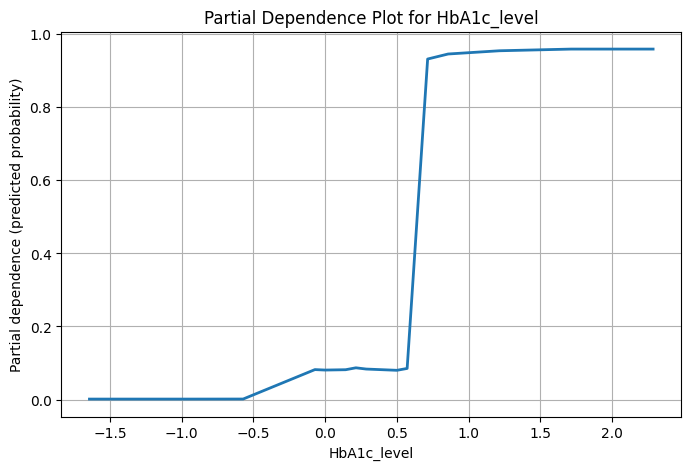

In [388]:
x_vals = pdp.grid_values[0]   # HbA1c_level vrednosti
y_vals = pdp.average[0]       # prosečna predikovana verovatnoća

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, linewidth=2)
plt.xlabel('HbA1c_level')
plt.ylabel('Partial dependence (predicted probability)')
plt.title('Partial Dependence Plot for HbA1c_level')
plt.grid(True)
plt.show()

### The PDP reveals a threshold-like, non-linear effect of HbA1c_level on the model’s predictions. At lower values of HbA1c_level, the predicted probability of the positive class remains close to zero. Around a standardized value of approximately 0.5, the model exhibits a sharp increase in predicted probability, followed by a plateau at higher values, indicating saturation.”

That being said, if we look at the clinical data:

- The HbA1c test measures your average blood sugar over 2-3 months, showing how well diabetes is managed; 
- levels below 42 mmol/mol (5.7%) are normal, 42-47 mmol/mol (5.7%-6.4%) indicate prediabetes, and 48 mmol/mol (6.5%) or higher confirms diabetes


This clinical interpretation is consistent with the observed PDP pattern. The sharp increase in predicted probability around this range suggests that the model has learned a strong discriminative signal associated with HbA1c values exceeding the diagnostic threshold for diabetes. Beyond this point, further increases in HbA1c do not substantially change the predicted probability, resulting in a saturation effect

Overall, the PDP analysis confirms that HbA1c_level is a clinically meaningful and dominant predictor in the model, exhibiting a threshold-based effect aligned with established diagnostic criteria for diabetes.

--- 

In [346]:
pdp_2 = partial_dependence(
    best_model,
    X_test,
    'heart_disease',
    percentiles=(0.1,0.9),
    grid_resolution=100,
    kind='average'
)

c:\Users\Admin\novo_dateset\Python Data Science - Learning Path\My exercises\Master\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 'heart_disease' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


In [347]:
grid_values2 = pdp_2.grid_values
average2 = pdp_2.average

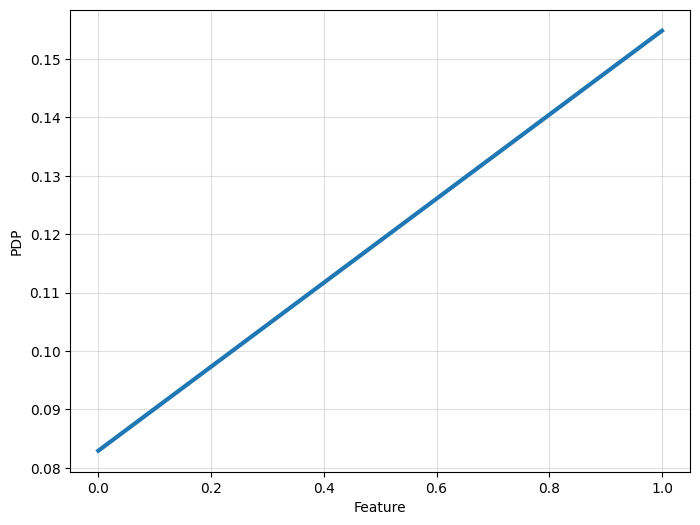

In [354]:
plt.figure(figsize=(8,6))
plt.plot(grid_values2[0],average2[0],linewidth=3,label='Effect of feature on target')
plt.xlabel('Feature')
plt.ylabel('PDP')
plt.grid(alpha=.4)
plt.show()

In [ ]:
f_list = feature_importance.iloc[:,:1]
f_list =np.array(f_list)
f_list[0]

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'gender_Female', 'gender_Male',
       'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_former', 'smoking_history_never'],
      dtype='object')